In [95]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import joblib
import matplotlib as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,MinMaxScaler
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

In [96]:
data=pd.read_csv(r'C:\Users\Acer\Desktop\python training\input\breast-cancer.csv')

In [97]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [98]:
data.shape

(569, 32)

In [99]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [100]:
print(data.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')


In [101]:
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

In [102]:
X=data[['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']]

In [103]:
y=data[['id']]

In [104]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [105]:
data.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [106]:
data.drop_duplicates(inplace=True)

In [107]:
imputer = SimpleImputer(strategy='mean')

In [108]:
numeric_cols = data.select_dtypes(include=['int64','float64']).columns

data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

In [109]:
# Diagnosis:
# M = Malignant
# B = Benign

In [110]:
encoder = LabelEncoder()

data['diagnosis'] = encoder.fit_transform(data['diagnosis'])

In [111]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [113]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [114]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [115]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [116]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [117]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores.mean())

0.9700978108989288


In [118]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':[3,5,7],
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.05]
}

grid = GridSearchCV(
    XGBClassifier(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [119]:
from sklearn.metrics import classification_report

pred = xgb.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



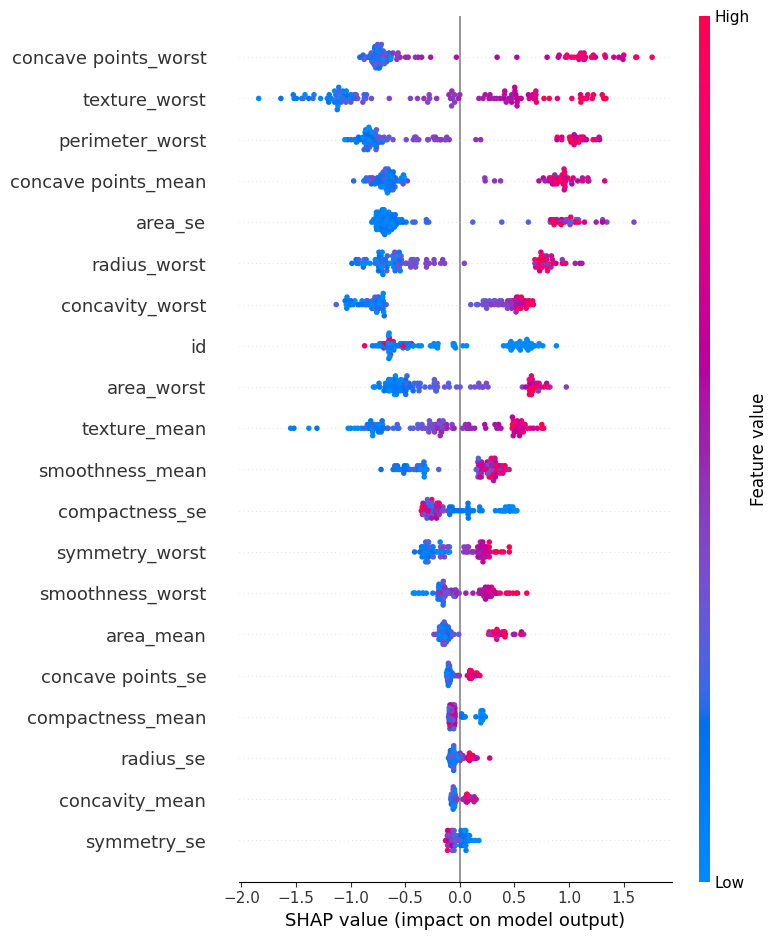

In [120]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [121]:
from fpdf import FPDF

In [122]:
pdf = FPDF()

pdf.add_page()

pdf.set_font("Arial", size=14)

pdf.cell(200,10,txt="Breast Cancer Prediction Report",ln=True)

pdf.output("report.pdf")

''

In [132]:
import streamlit as st
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pickle

In [134]:
st.set_page_config(
    page_title="AI Breast Cancer Prediction",
    page_icon="🩺",
    layout="wide"
)

2026-05-25 14:51:44.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [135]:
st.title("🩺 AI Breast Cancer Prediction System")

st.write("""
This AI system predicts whether breast cancer is malignant or benign
using Machine Learning models.
""")

2026-05-25 14:52:01.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:52:01.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:52:01.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:52:01.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:52:01.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:52:01.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [136]:
df = pd.read_csv(r"C:\Users\Acer\Desktop\python training\breastcancerproject\breast-cancer.csv")

In [138]:
st.subheader("📊 Dataset Preview")

st.dataframe(df.head())

2026-05-25 14:54:05.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:54:05.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:54:05.144 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:54:05.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:54:05.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:54:05.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [142]:

st.write(df.shape)

2026-05-25 14:55:32.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:32.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:32.876 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:32.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:32.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:32.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [143]:
st.subheader("❓ Missing Values")

st.write(df.isnull().sum())

2026-05-25 14:55:35.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:35.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:35.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:35.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:35.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:55:35.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [144]:
df = df.dropna()

In [145]:
st.subheader("🎯 Diagnosis Distribution")

st.bar_chart(df['diagnosis'].value_counts())

2026-05-25 14:56:11.663 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:11.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:11.665 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:11.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:11.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:11.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

2026-05-25 14:56:29.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:29.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:29.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:30.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:30.766 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:30.767 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:56:30.767 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

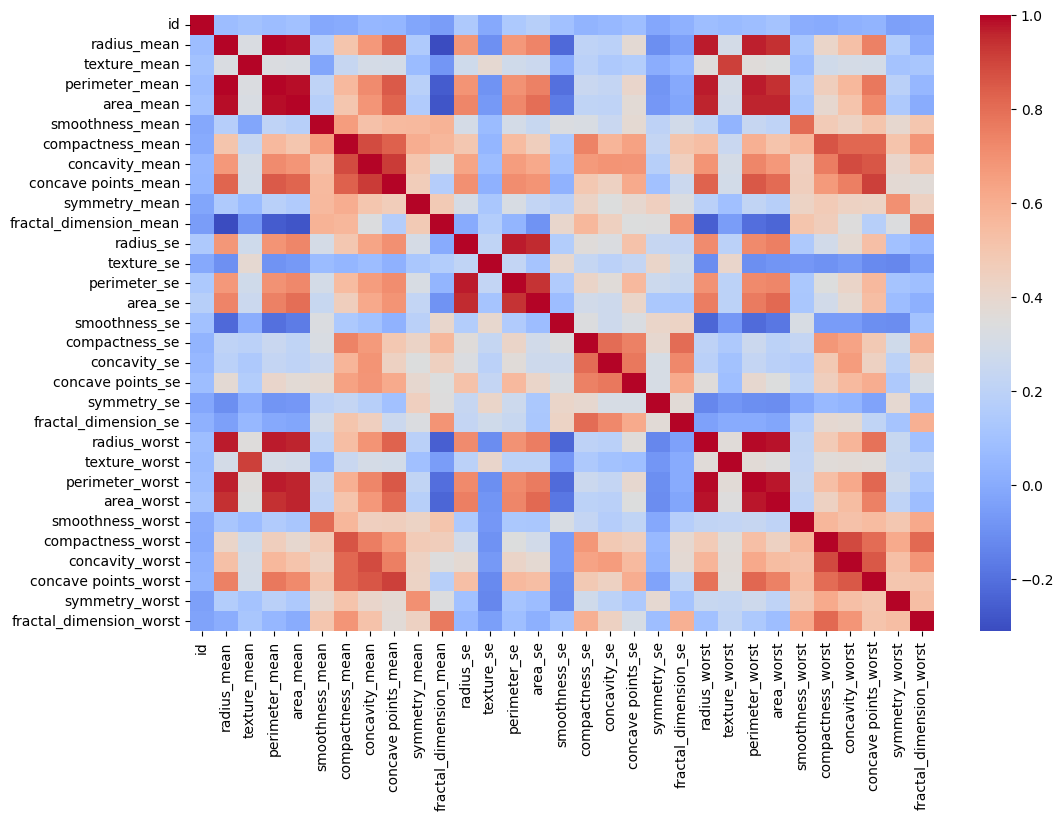

In [146]:
st.subheader("🔥 Correlation Heatmap")

fig, ax = plt.subplots(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    ax=ax
)

st.pyplot(fig)

In [147]:
label_encoder = LabelEncoder()

df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])

In [148]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [150]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier()
}

In [151]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [152]:
results_df = pd.DataFrame(results)

st.subheader("📊 Model Comparison")

st.dataframe(results_df)

2026-05-25 14:58:50.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:58:50.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:58:50.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:58:50.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:58:50.315 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:58:50.316 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [153]:
best_model = XGBClassifier()

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

In [154]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

st.subheader("📌 Confusion Matrix")

st.pyplot(fig)

2026-05-25 14:59:20.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:20.323 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:20.324 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:20.325 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:20.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:20.440 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:20.440 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [155]:
st.subheader("📋 Classification Report")

report = classification_report(
    y_test,
    predictions
)

st.text(report)

2026-05-25 14:59:34.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:34.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:34.786 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:34.809 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:34.811 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 14:59:34.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [156]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [157]:
st.subheader("📈 Feature Importance")

st.bar_chart(
    importance_df.set_index("Feature")
)

2026-05-25 15:00:06.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:06.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:06.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:06.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:06.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:06.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [158]:
st.subheader("🧠 Predict New Patient")

input_data = []

for col in X.columns:

    value = st.number_input(f"Enter {col}")

    input_data.append(value)

2026-05-25 15:00:23.079 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:23.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:23.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:23.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:23.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:23.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:23.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:23.090 Session state does not function when running a script without `streamlit run`
2026-05-25 15:00

In [159]:
if st.button("Predict"):

    prediction = best_model.predict([input_data])[0]

    if prediction == 1:
        st.error("⚠️ Malignant Cancer Detected")

    else:
        st.success("✅ Benign")

2026-05-25 15:00:45.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:45.564 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:45.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:45.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:45.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:00:45.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [160]:
with open("model.pkl", "wb") as f:

    pickle.dump(best_model, f)

In [161]:
st.markdown("""
<style>

.stApp {
    background-color: #f5f7fa;
}

h1 {
    color: #E63946;
    text-align: center;
}

.stButton>button {
    border-radius: 10px;
    height: 50px;
    width: 100%;
    font-size: 18px;
}

</style>
""", unsafe_allow_html=True)

2026-05-25 15:01:17.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:01:17.612 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 15:01:17.614 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

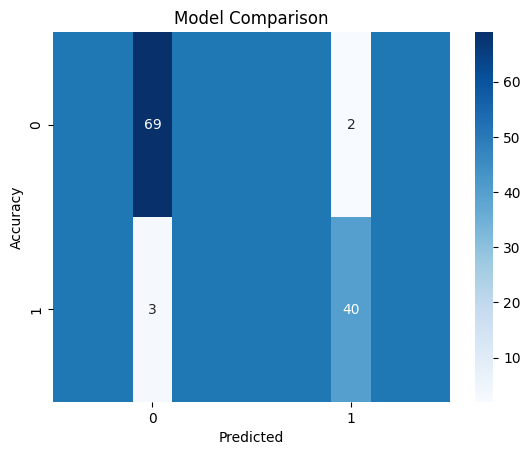

In [162]:
models = ['LR','RF','SVM','KNN','XGB']

accuracy = [94,97,95,93,98]

plt.bar(models, accuracy)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()